# 1+1D Laser ablation

This notebook demonstrates how to solve the **problem of laser ablation** equation using Physics-Informed Neural Networks (PINNs).The governing equations are:

$$v_x = \alpha_3\frac{\partial h}{\partial x} + \alpha_1^2(\frac{\partial h}{\partial x}\frac{\partial v_x}{\partial x}+h\frac{\partial^2 v_x}{\partial x^2})$$

$$\frac{\partial h}{\partial t}= -v_x\frac{\partial h}{\partial x}-h\frac{\partial v_x}{\partial x}+1-h$$

where $h$ is the density of the material and $v_x$ is velocity density of the material. We have boundary conditions

$$v_x(\pm x_{border}, t)=0$$
$$h(x, 0)= 1 - \sigma((x+x_{cut})/\sigma_{cut})\sigma((x_{cut}-x)/\sigma_{cut})$$

where $\sigma=1/(1+x)$.

where:
- $\omega$ is the angular frequency squared
- $\beta$ is the damping coefficient
- $x(t)$ is the displacement

This problem has the following callenges:

- The initial condition is very sharp in a very small region close to the center compared to the space.
- The problem is advective

In addition we have an axial symmetry around x.

We will solve this problem:

- Using FBPINN method to be able to focus better in the diferent regions of the space
- Using not uniform sampling to focus the loss on the interest region around the cut
- Exploiting the symmetry
- Imposing the initial condition as a hard constrain. This will facilitate the network to find the correct solution.

In [1]:
import pinns
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp

## Define the problem

### Parameters

In [2]:
#Physical parameters
alpha1 = 1.0
alpha3 = .1
#Parameters for the space of simulation
t_max = 0.1
x_border = 5.0
#Parameters of the cut
cut_border=0.04
sigma_border=0.005
#Parameters for the sampling
sigma_cut_sampling = 0.1
w = 0.2

### Domain

For the domain we are going to set a 2D domain and we are going to define the convention (x, t) for the ordering of the columns.

In addition we are going to sample inside the domain non-uniformly to give more importance to the surroundings of the cut.

- Uniform in time
- Mixture of uniform in all space and normal around the cut

$p(x,t) = Uniform(t;0,tmax)\text{Mixture}(\text{Uniform}(x;0, x_{border}), \text{Normal}(x;0,\sigma_{cut sampling}); w, (1-w))$

In [3]:
# Column Convention
# X: (x,t)
def sampler(X, params):

    w = params["fixed"]["w"]
    x_border = params["fixed"]["x_border"]
    sigma_cut_sampling = params["fixed"]["sigma_cut_sampling"]

    n = int(np.round(X.shape[0]*w))
    x1 = sp.uniform.ppf(X[:n,0:1], loc=-x_border, scale=2*x_border)
    x2 = sp.norm.ppf(X[n:,0:1], scale=sigma_cut_sampling)
    x = np.vstack((x1,x2))
    t = X[:,1:2]

    return np.hstack((x, t))

x_subdomains = [-10, -5.0, -4.5, -4.0, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, -0.25, -0.1, -0.05, 0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 10]
t_subdomains = np.linspace(0,t_max,5)
domain = pinns.DomainCubicPartition(
    [x_subdomains, t_subdomains],
    sampling_method="uniform",
    sampling_transform=sampler
)

### The equation's residuals

In [4]:
# Column Convention
# X: (x,t)
# V: (h,vx)
def model_laser_ablation(X, V, params):

    alpha1 = params["fixed"]["alpha1"]
    alpha3 = params["fixed"]["alpha3"]

    x = X[:, 0:1]
    t = X[:, 1:2]

    h = V[:, 0:1]
    vx = V[:, 1:2]

    dh_x = pinns.derivative(V, X, 0, (0,))
    dh_t = pinns.derivative(V, X, 0, (1,))

    dvx_x = pinns.derivative(V, X, 1, (0,))
    dvx_t = pinns.derivative(V, X, 1, (1,))
    dvx_xx = pinns.derivative(V, X, 1, (0, 0))

    # v_j = alpha3 d_dx h + 4 alpha1^2 (d_dx h d_dx vx + h dd_dxx vx)
    eq1 = vx - alpha3 * dh_x - 4 * alpha1**2 * (dh_x * dvx_x + h * dvx_xx)

    # dh_dt = -vx d_dx h - h d_dx vx + 1 - h
    eq2 = dh_t + vx * dh_x + h * dvx_x - 1 + h

    return eq1, eq2

### Define the boundary conditions

In here we do not define the initial boundary condition for $h$ as we are going to define it as a hard constraint.

This boundary conditions are soft boundaries that will appear as additional terms in the loss functions. So they will be rewarded but not hard imposed,

In [5]:
# vx boundary conditions at x_min and x_border
domain.add_dirichlet(
    boundary = (0, None),  # x = x_min boundary, all t
    value = 0.0,
    component=1,
    name="vx(-x_border, t)"
)
domain.add_dirichlet(
    (1, None),  # x = x_border boundary
    0.0,
    component=1,
    name="vx(x_border, t)"
)


DomainCubicPartition(xmin=[-10.0, 0.0], xmax=[10.0, 0.1], n_subdomains_per_dim=[28, 4], total_subdomains=112, n_conditions=2)

### Assemble the problem

In [6]:
problem = pinns.Problem(
    domain,
    model_laser_ablation,
    input_names=["x", "t"],
    output_names=["h", "vx"],
    output_range=[(0, 1), (-1, 1)],
    params={"alpha1":alpha1, 
            "alpha3":alpha3, 
            "x_border":x_border, 
            "cut_border":cut_border,
            "sigma_border":sigma_border,
            "w":w, 
            "sigma_cut_sampling": sigma_cut_sampling},
)

## Define the solver (FBPINN)

A neural network pass as the ones written in the `pinns` package work in the following way:

1. initial transform (optional) 
2. normalize (optional but recomended) 
3. NN
4. unnormalization (optional but recomended)
5. final transform (optional)

Since our problem is mirror-symmetric in x, we will help the NN if we make it just predict in (0,x_border). So we impose an initial transform (1.).

$$x \rightarrow abs(x)$$
$$t \rightarrow t$$

be carefull that the output variables behave under reflection symmetry as,

$$h(x) = h(-x)$$
$$v_x(x) = -v_x(-x)$$

so $v_x$ is antisymmetric and we will have to take that into account by undoing the symmetry in a final transform.

Additionally, as we mentined above, instead of imposing the initial condition as a soft boundary, we are going to hard code it in the network. For that we will define a final transform of the ansatz:

$$h(x,t) = h(x,0) + t\textit{NN}_0(x,t)$$

$$v_x(x,t) = \text{sign}(x)\tanh^2(x)\textit{NN}_1(x,t)$$

which immediately can bee seen that fulfills the initial condition and the symmetries. Making the hard constrain makes the model to learn faster the initial condition and allows the neural network just to learn modifications to this initial condition helping the convergence. Take as a note that we incorporated a $\text{sign}(x)\tanh^2(x)x$ to undo the symmetry transform and to force the solution to be $v_x=0$ and $v'_x=0$ at the boundary from symmetry.


In [7]:
def input_transform(X, params):

    x = torch.abs(X[:, 0:1])
    t = X[:, 1:2]

    return torch.hstack((x, t))

def output_transform(X, V, params):

    x_border = params["fixed"]["cut_border"]
    sigma = params["fixed"]["sigma_border"]

    x = X[:, 0:1]
    t = X[:, 1:2]

    NN0 = V[:, 0:1]
    NN1 = V[:, 1:2]
    
    # Numerically stable version using torch.sigmoid
    # f = 0 inside cut (|x| < x_border), f = 1 outside
    s1 = torch.sigmoid((x + x_border) / sigma)  # left edge
    s2 = torch.sigmoid((x_border - x) / sigma)  # right edge
    f = 1 - s1 * s2
    
    h = f + t * NN0
    vx = torch.sign(x)*torch.tanh(x)**2*NN1

    return torch.hstack((h, vx))

Finally we can create the network. There is just one subtlety left. Domain expands in (-x, x) and since FBPINN makes small networks for each partition, we will be generating an independent network for all positions in space. But since we are using the symmetry, this would waste networks in the negative domain which will not be trained. 

We can specify then partitions that should not have assigned a network.

In [8]:
baseNetwork = pinns.FNN([2, 32, 2], activation="tanh")

# Select from the subdomains the only ones active
active_mask = [sub.xmin[0] >= 0 for sub in domain.subdomains]

# Create the network
network = pinns.FBPINN(
    domain,
    baseNetwork,
    normalize_input=True,
    unnormalize_output=True,
    input_transform=input_transform,
    output_transform=output_transform,
    active_subdomains=active_mask
)

## Training Configuration

Epoch     0 | Loss: 5.3420e+00 | PDE: 5.31e+00 | BCs: [1.53e-02, 1.47e-02]


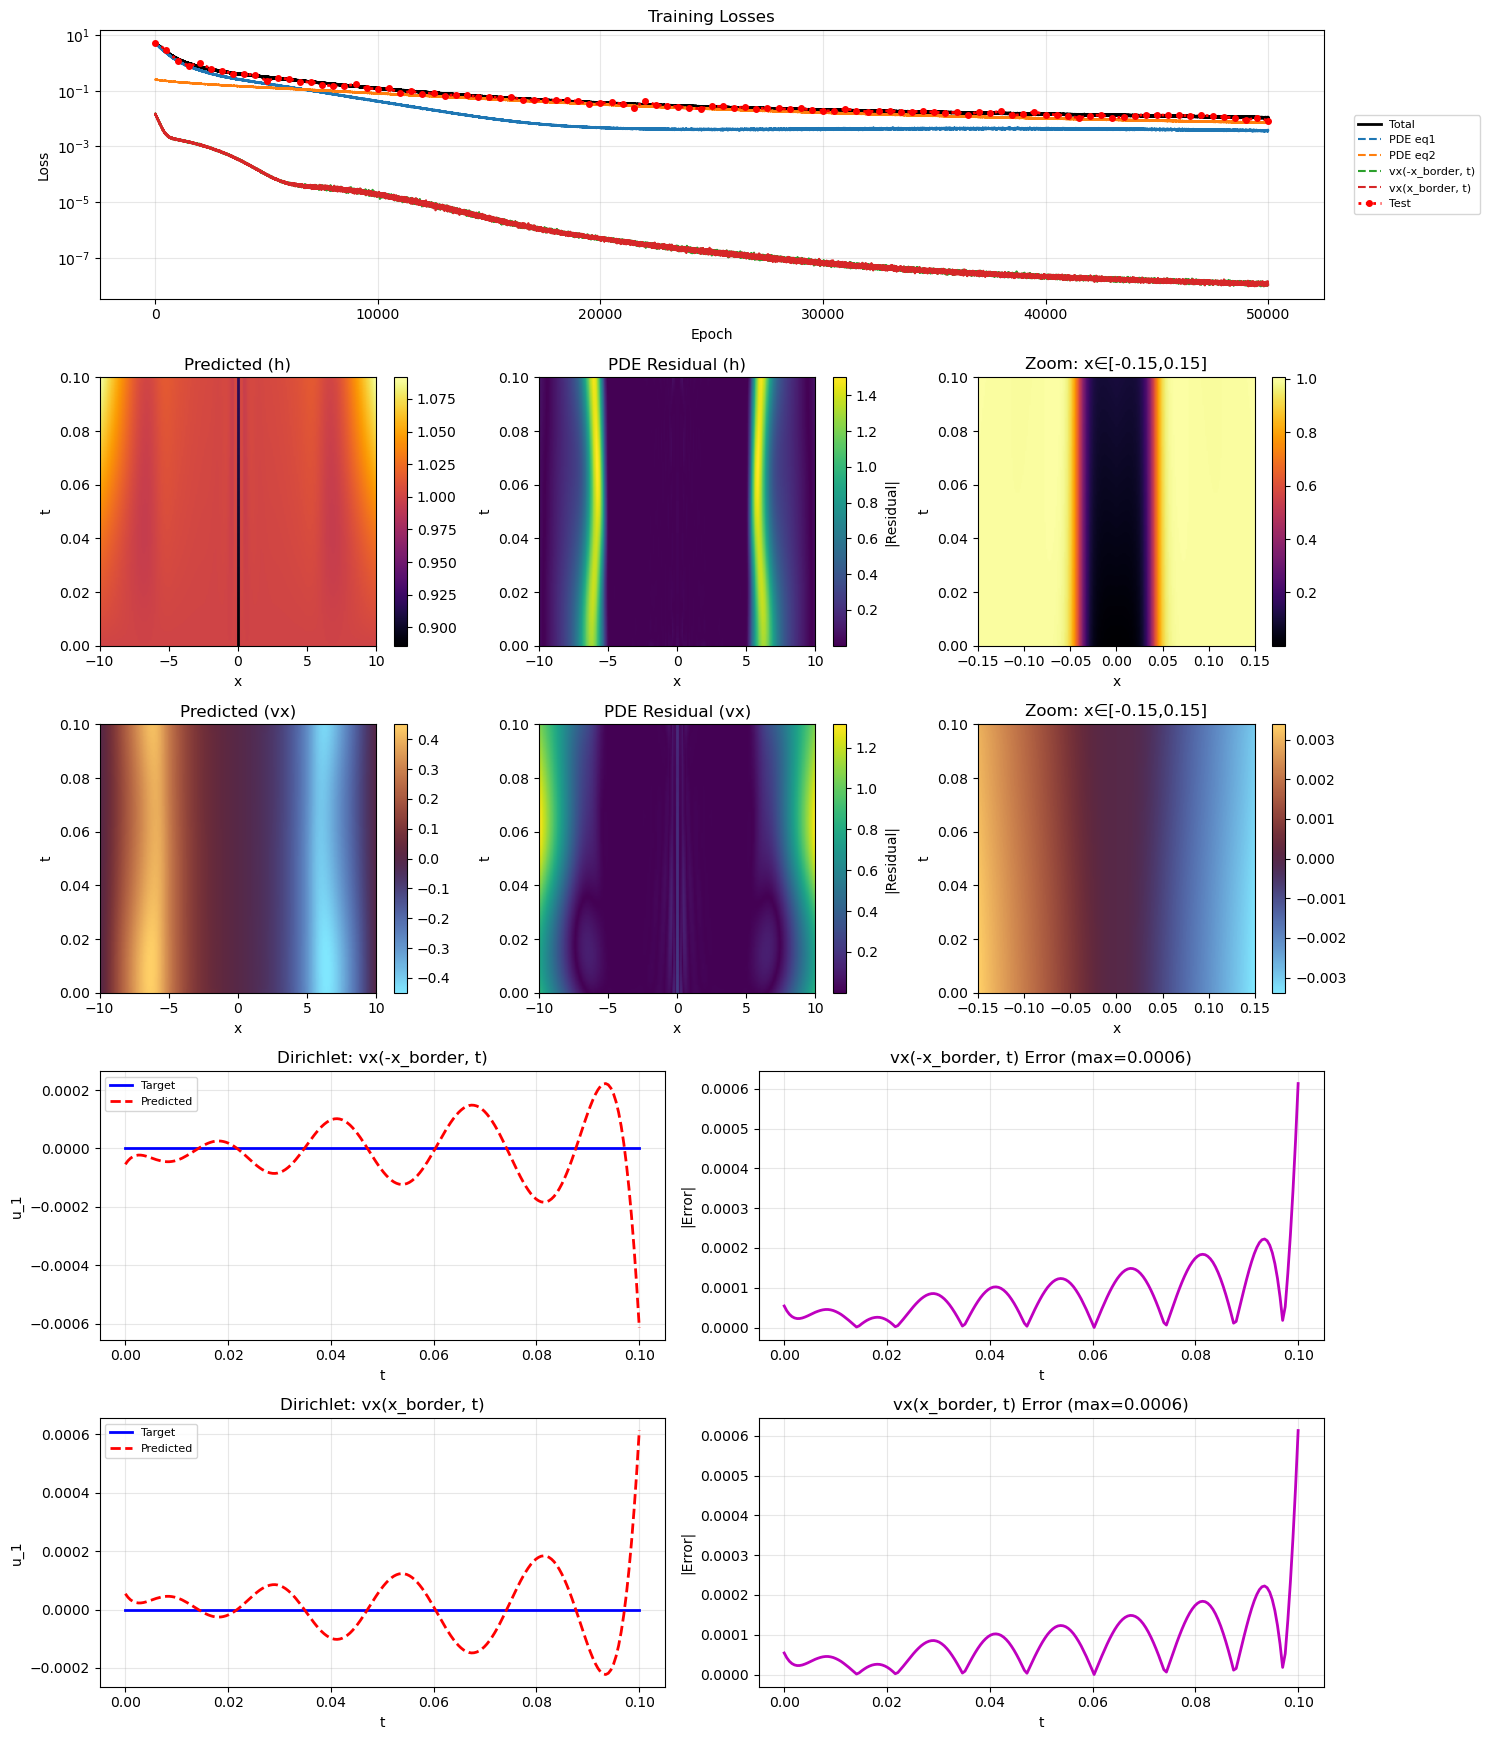

Epoch   500 | Loss: 2.5386e+00 | PDE: 2.53e+00 | BCs: [2.62e-03, 2.58e-03]
Epoch  1000 | Loss: 1.3897e+00 | PDE: 1.39e+00 | BCs: [1.77e-03, 1.75e-03]
Epoch  1500 | Loss: 9.5630e-01 | PDE: 9.54e-01 | BCs: [1.38e-03, 1.37e-03]
Epoch  2000 | Loss: 7.2175e-01 | PDE: 7.20e-01 | BCs: [1.09e-03, 1.15e-03]
Epoch  2500 | Loss: 5.9500e-01 | PDE: 5.93e-01 | BCs: [8.60e-04, 8.69e-04]
Epoch  3000 | Loss: 5.0706e-01 | PDE: 5.06e-01 | BCs: [6.24e-04, 6.49e-04]
Epoch  3500 | Loss: 4.2945e-01 | PDE: 4.29e-01 | BCs: [4.14e-04, 4.00e-04]
Epoch  4000 | Loss: 3.8600e-01 | PDE: 3.85e-01 | BCs: [2.78e-04, 2.60e-04]
Epoch  4500 | Loss: 3.4781e-01 | PDE: 3.47e-01 | BCs: [1.63e-04, 1.54e-04]
Epoch  5000 | Loss: 3.1150e-01 | PDE: 3.11e-01 | BCs: [9.50e-05, 9.36e-05]
Epoch  5500 | Loss: 2.7689e-01 | PDE: 2.77e-01 | BCs: [6.34e-05, 6.26e-05]
Epoch  6000 | Loss: 2.5707e-01 | PDE: 2.57e-01 | BCs: [4.50e-05, 4.54e-05]
Epoch  6500 | Loss: 2.3541e-01 | PDE: 2.35e-01 | BCs: [4.08e-05, 3.95e-05]
Epoch  7000 | Loss: 2.097

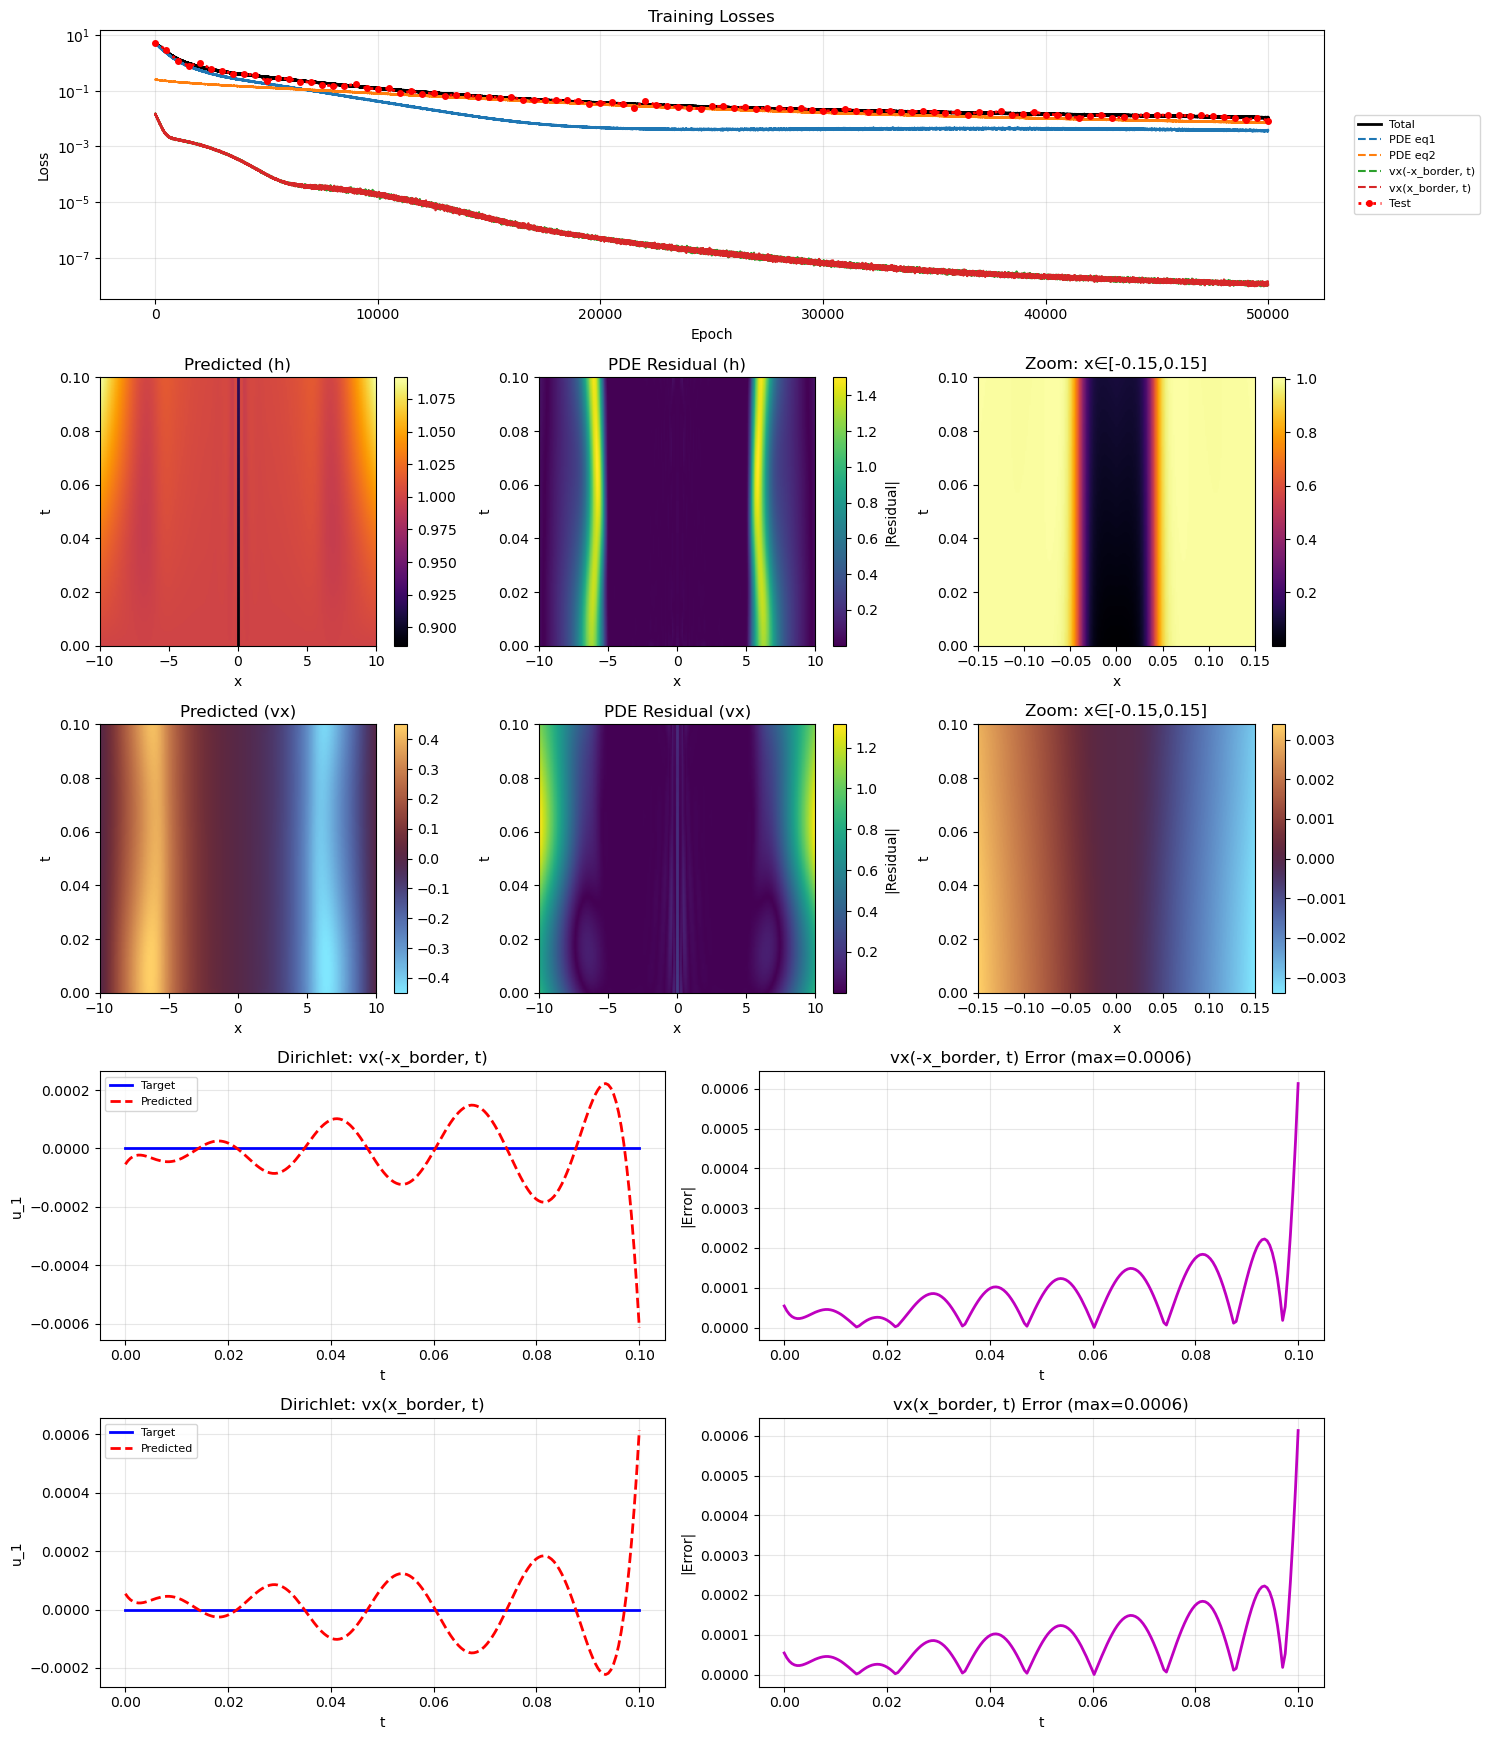

In [9]:
trainer = pinns.Trainer(
    problem,
    network
)

trainer.compile(
    train_samples={
        "pde": 10000,
        "vx(x_border, t)": 1000,
        "vx(-x_border, t)": 1000
    },
    test_samples={
        "pde": 100,
        "vx(x_border, t)": 100,
        "vx(-x_border, t)": 100
    },
    weights={
        "pde": 1.0,
        "vx(x_border, t)": 1.0,
        "vx(-x_border, t)": 1.0
    },
    optimizer="adam",
    learning_rate=1e-5,
    epochs=50000,
    print_each=500,
    show_plots=True,
    show_subdomains=False,
    show_sampling_points=False,
    plot_regions=[((-0.15, 0.15), None)],  # x in [-0.15, 0.15], full t range
    plot_n_points=200,
    profile=False,
)

trainer.train()